# **Importing libraries**

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import sys
import librosa
import torchvision
import numpy as np

import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd

from tqdm import tqdm
%matplotlib inline

from torchsummary import summary
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# Get Computtional Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Importing the Dataset

In questa **Fase 1** (baseline), il dataset RAVDESS viene suddiviso in modo **casuale** 
(random split, seed fisso per riproducibilità), indipendentemente dall'identità dello speaker.
Traning 70%
Validation 15%
Test 15%


In [3]:
# Percorso base del dataset RAVDESS su Kaggle
# (Kaggle salva automaticamente i dataset nella cartella /kaggle/input/)
DATASET_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"

# Mappatura delle emozioni (il 3° numero nel nome del file RAVDESS)
# Mappatura delle emozioni (Adattata per partire da 0)
emotion_map = {
    0: 'Neutral',
    1: 'Calm',
    2: 'Happy',
    3: 'Sad',
    4: 'Angry',
    5: 'Fearful',
    6: 'Disgust',
    7: 'Surprised'
}


In [4]:
import os
import torch
from torch.utils.data import Dataset

class RavdessDataset(Dataset):
    def __init__(self, root_dir=DATASET_PATH, subset="training", emotions=None):
        """
        emotions: lista di stringhe con i codici delle emozioni da tenere (es. ["03", "04"] per Felice e Triste).
                  Se None, prende tutte le emozioni.
        """
        self.root_dir = root_dir
        self.emotions = emotions if emotions is not None else []
        self._walker = [] # Conterrà i percorsi dei file audio selezionati

        # 1. Trova tutti i file .wav nelle sottocartelle
        all_files = []
        for dirpath, _, filenames in os.walk(root_dir):
            for f in filenames:
                if f.endswith(".wav"):
                    all_files.append(os.path.join(dirpath, f))

        # 2. Filtra e suddividi il dataset
        for file_path in all_files:
            filename = os.path.basename(file_path)
            
            # Rimuove ".wav" e divide la stringa usando i trattini
            parts = filename.replace(".wav", "").split("-")
            
            # Controlla che il file sia effettivamente nel formato RAVDESS (7 parti)
            if len(parts) != 7:
                continue
                
            emotion = parts[2]
            
            # Filtra per etichetta (emozione)
            if len(self.emotions) > 0 and emotion not in self.emotions:
                continue # Salta questo file e passa al prossimo

            
            
            self._walker.append(file_path)
    def __len__(self):
        return len(self._walker)

    def __getitem__(self, idx):
        file_path = self._walker[idx]
        waveform, sample_rate = torchaudio.load(file_path)
        
        # Prende il nome del file e divide i pezzi
        filename = os.path.basename(file_path)
        parts = filename.replace(".wav", "").split("-")
        
        # Estrae i vari ID dal nome del file
        emotion_label = parts[2]
        utterance_number = int(parts[4])  # Frase 1 o 2
        speaker_id = int(parts[6])        # Attore da 1 a 24
        
        # 1. Converti in mono se stereo (media dei canali)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)  # [1, T]

        # --- PRE-PROCESSING (TRIMMING E NORMALIZZAZIONE) ---
        wav_np = waveform.squeeze().numpy()
        
        # Trimming
        wav_trimmed, _ = librosa.effects.trim(wav_np, top_db=30)
        
        # Normalizzazione
        wav_norm = librosa.util.normalize(wav_trimmed)
        
        # Ritorno a Tensore PyTorch
        waveform = torch.tensor(wav_norm).unsqueeze(0)  # [1, T]
        #Ricampionamento
        resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
        waveform = resampler(waveform)
        sample_rate = 16000
        # Converte l'etichetta dell'emozione in un tensore
        # (Sottraiamo 1 perchè le etichette dei file partono da 1)
        label_tensor = torch.tensor(int(emotion_label) - 1, dtype=torch.long)
        
        # Restituisce l'audio processato e tutte le etichette/metadati
        return waveform, sample_rate, label_tensor, speaker_id, utterance_number

In [5]:
from torch.utils.data import random_split

# Seleziono tutte le emozioni previste dal dataset
emozioni_scelte = ["01", "02", "03", "04", "05", "06", "07", "08"]

# ── Carica l'intero dataset (nessuna suddivisione per speaker) ──────────────
full_dataset = RavdessDataset(emotions=emozioni_scelte)
print(f"Totale campioni disponibili: {len(full_dataset)}")

# ── Suddivisione casuale 70 / 15 / 15 ──────────────────────────────────────
total   = len(full_dataset)
n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val   # i rimanenti vanno al test

# Seed fisso per riproducibilità degli esperimenti
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

print(f"Training   : {len(train_dataset)} campioni  ({len(train_dataset)/total*100:.1f}%)")
print(f"Validation : {len(val_dataset)} campioni  ({len(val_dataset)/total*100:.1f}%)")
print(f"Testing    : {len(test_dataset)} campioni  ({len(test_dataset)/total*100:.1f}%)")
print()
print("Nota: la suddivisione è CASUALE (random split).")
print("La valutazione speaker-independent sarà implementata nella Fase 2.")

Totale campioni disponibili: 2880
Training   : 2015 campioni  (70.0%)
Validation : 432 campioni  (15.0%)
Testing    : 433 campioni  (15.0%)

Nota: la suddivisione è CASUALE (random split).
La valutazione speaker-independent sarà implementata nella Fase 2.


# Esplorazione dei dati

Sample metadata. Label: 1, Speaker: 15, Utterance no. 2
Shape of waveform: torch.Size([1, 41472])
  Number of channels: 1
  Number of samples: 41472
Sample rate of waveform: 16000 Hz
Seconds: 2.592 s


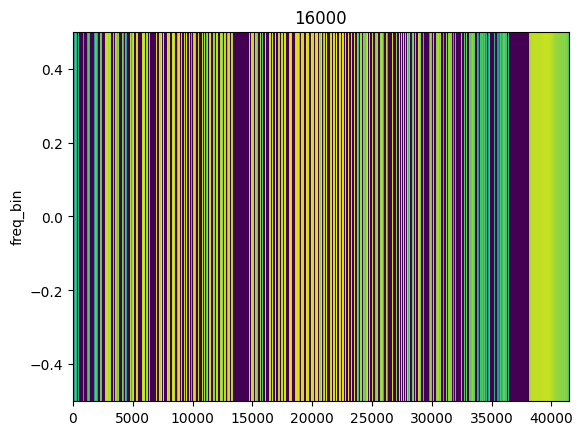

In [6]:
idx = 1 #seleziona un campione dal dataset es. indice=1

waveform, sample_rate, label, speaker_id, utterance_number = train_dataset[idx]

print(f"Sample metadata. Label: {label}, Speaker: {speaker_id}, Utterance no. {utterance_number}")
print("Shape of waveform: {}".format(waveform.size()))
print("  Number of channels: {}".format(waveform.size()[0]))
print("  Number of samples: {}".format(waveform.size()[1]))
print("Sample rate of waveform: {} Hz".format(sample_rate))


# TASK: WAVEFORM PLOT

#traccia la forma d'onda e stampane la forma.
def plot_waveform(waveform, sr, title="Waveform", ax=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr

    if ax is None:
        _, ax = plt.subplots(num_channels, 1)
    ax.plot(time_axis, waveform[0], linewidth=1)
    ax.grid(True)
    ax.set_xlim([0, time_axis[-1]])
    ax.set_title(title)


def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")


def plot_fbank(fbank, title=None):
    fig, axs = plt.subplots(1, 1)
    axs.set_title(title or "Filter bank")
    axs.imshow(fbank, aspect="auto")
    axs.set_ylabel("frequency bin")
    axs.set_xlabel("mel bin")

num_campioni=waveform.shape[1]
sec=num_campioni/sample_rate
print("Seconds: {} s".format(sec))

plot_spectrogram(waveform, sample_rate)


Run the following cell and listen to the sample

In [7]:
print(f"Listen to sample no. {idx} with utterance_number: {utterance_number}")
print(f" Speaker {speaker_id} saying '{label}'")
print()
#Ascolta lo stesso campione con "ipd.Audio(<forma d'onda>, )"
ipd.display(ipd.Audio(waveform.numpy(), rate=sample_rate))

Listen to sample no. 1 with utterance_number: 2
 Speaker 15 saying '1'



In [8]:

print("Counting number of labels in the dataset (be patient) ...")

# 1. Estrai i valori numerici dal dataset (gestendo sia i tensori che i numeri normali)
raw_labels = [d[2].item() if hasattr(d[2], 'item') else d[2] for d in train_dataset]

# 2. Calcola le frequenze con Pandas
counts = pd.Series(raw_labels).value_counts()

# 3. Ottieni la lista dei nomi delle emozioni (es. ['Happy', 'Sad', ...])
# Uso .get() per sicurezza, così se spunta un numero non previsto non va in crash
labels_testo = [emotion_map.get(lbl, f"Sconosciuto ({lbl})") for lbl in counts.index.tolist()]

# 4. Ottieni il dizionario completo {Nome_Emozione: Conteggio}
label_counts_dict = {emotion_map.get(k, f"Sconosciuto ({k})"): v for k, v in counts.items()}

# Stampa i risultati!
print("Le mie label sono:", labels_testo)
print("I conteggi per ogni label sono:", label_counts_dict)

Counting number of labels in the dataset (be patient) ...
Le mie label sono: ['Fearful', 'Happy', 'Sad', 'Disgust', 'Angry', 'Calm', 'Surprised', 'Neutral']
I conteggi per ogni label sono: {'Fearful': 289, 'Happy': 273, 'Sad': 271, 'Disgust': 268, 'Angry': 265, 'Calm': 262, 'Surprised': 255, 'Neutral': 132}


# **Ricampionamento**
I file audio del dataset RAVDESS sono originariamente registrati a una frequenza di campionamento (Sample Rate) di 48 kHz (48.000 valori al secondo). Se ricampioni il segnale a 16 kHz, riduci la quantità di dati in ingresso a un terzo.

In [9]:

# 1. Definisci le variabili di input (Supponiamo che l'audio sia a 16 kHz)
original_sample_rate = sample_rate # Esempio di frequenza originale 48

# 2. Definisci la frequenza target
resample_freq = 16000  # Vogliamo ricampionare a 16 kHz

# 3. Inizializza la trasformazione Resample
# Il primo argomento è la frequenza originale, il secondo è la frequenza target.
resampler = T.Resample(
    orig_freq=original_sample_rate,
    new_freq=resample_freq
)

# 4. Applica la trasformazione
waveform_16k = resampler(waveform)

sample_rate=resample_freq
waveform=waveform_16k;

print("sample_rate",sample_rate)

sample_rate 16000


Wavefrom, Spectogram e Filter Bank con Ricampionamento

Dopo preprocessing → shape: torch.Size([1, 41472]), SR: 16000 Hz


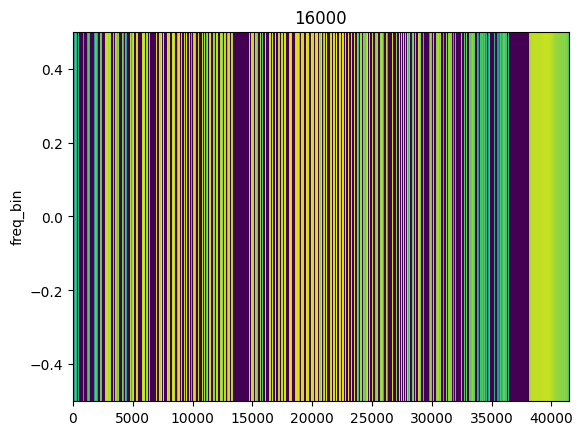

In [10]:
print(f"Dopo preprocessing → shape: {waveform.shape}, SR: {sample_rate} Hz")
plot_spectrogram(waveform, sample_rate)
plt.show()

# Mel Spectrogram
Mel Spectrogram. Spettrogramma Mel. Utilizzare le trasformazioni di Torchaudio per trasformare i dati campione in un'immagine, ovvero lo spettrogramma Mel. 

In [11]:
!pip install librosa

In [12]:
torch.random.manual_seed(0)

indice_campione = 1  

# 1. Recupera l'indice reale mappato dal Subset
indice_reale = train_dataset.indices[indice_campione]

# 2. Accedi a _walker tramite il dataset originale
SAMPLE_SPEECH = train_dataset.dataset._walker[indice_reale]

print(f"File audio selezionato : {SAMPLE_SPEECH}")

File audio selezionato : /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_15/03-01-02-02-02-02-15.wav


Mel-Spectrogram shape: torch.Size([1, 128, 260])
MFCC shape:            torch.Size([1, 40, 260])


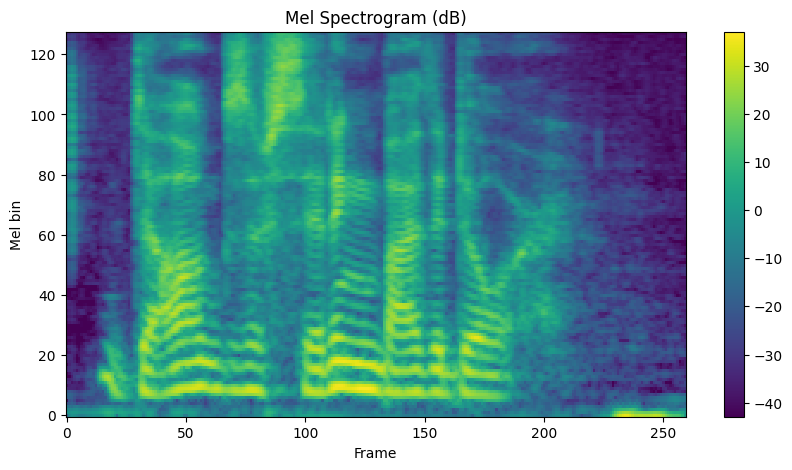

In [13]:

#torch.random.manual_seed(0)

n_fft = 1024 # Example: 25ms window for 16kHz corresponds to 400 samples (0.025 * 16000)
win_length = n_fft #lunghezza frame
hop_length = 160 # Example: 10ms hop length (tempo finestra ms*freqeunza campionamento=0.010 * 16000)
n_mels=128 # Example number of mel bands
n_mfcc= 40 # numero di coefficienti MFCC

#resampleFn, ricampionamento fatto sopra
resample_freq = sample_rate #16kHz

specgramFn  = T.Spectrogram(n_fft=n_fft, win_length=win_length,
                              hop_length=hop_length, power=2.0)
melscaleFn  = T.MelScale(n_mels=n_mels, sample_rate=resample_freq,
                          n_stft=n_fft//2+1)
amplitude_to_db_transform = T.AmplitudeToDB(stype='power', top_db=80)

resampled = waveform
# ── Pipeline MFCC ────────────────────────────────────────────────────────────
mfccFn = T.MFCC(
    sample_rate = resample_freq,
    n_mfcc      = n_mfcc,
    melkwargs   = {"n_fft": n_fft, "win_length": win_length,
                   "hop_length":hop_length, "n_mels": n_mels}
)

# ── Visualizzazione su campione ───────────────────────────────────────────────
resample_freq = sample_rate #16kHz
specgram   = specgramFn(resampled)
melspec    = melscaleFn(specgram)
dbmelspec  = amplitude_to_db_transform(melspec)
mfcc       = mfccFn(resampled)

print(f"Mel-Spectrogram shape: {dbmelspec.shape}")
print(f"MFCC shape:            {mfcc.shape}")

plt.figure(figsize=(10,5))
plt.xlabel('Frame');
plt.ylabel('Mel bin');
plt.imshow(dbmelspec[0], origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.title("Mel Spectrogram (dB)")
plt.show()


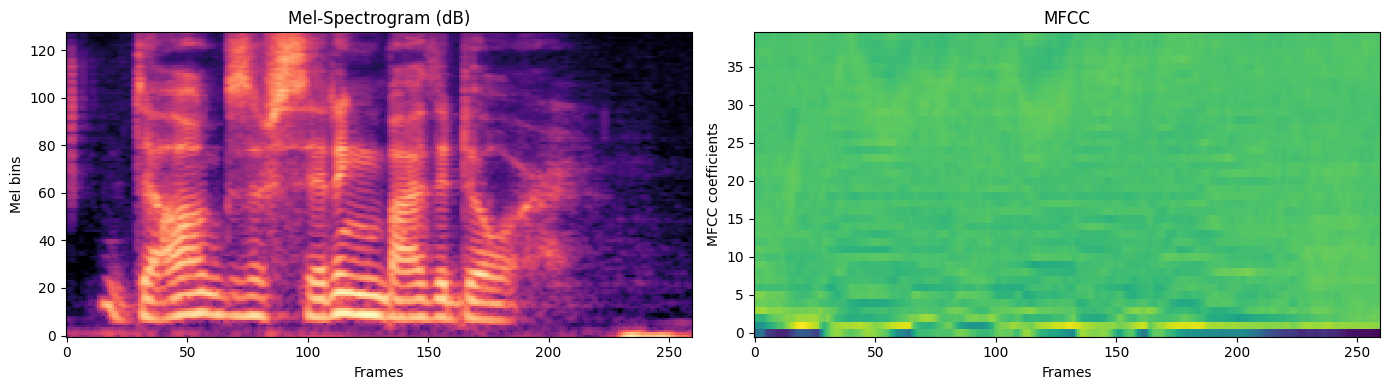

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].imshow(dbmelspec[0].numpy(), origin="lower", aspect="auto",
              interpolation="nearest", cmap='magma')
axs[0].set_title("Mel-Spectrogram (dB)"); axs[0].set_xlabel("Frames"); axs[0].set_ylabel("Mel bins")

axs[1].imshow(mfcc[0].numpy(), origin="lower", aspect="auto",
              interpolation="nearest", cmap='viridis')
axs[1].set_title("MFCC"); axs[1].set_xlabel("Frames"); axs[1].set_ylabel("MFCC coefficients")

plt.tight_layout(); plt.show()


# Formatting the data
Functions `label_to_index` and `index_to_label` are used to map (and encode) each word with its index in the list of labels.

In [15]:

# 1. Creiamo la mappa inversa
inverse_emotion_map = {v.lower(): k for k, v in emotion_map.items()}

def label_to_index(word):
    return torch.tensor(inverse_emotion_map[word.lower()])

def index_to_label(index):
    if torch.is_tensor(index): index = index.item()
    return emotion_map.get(index, f"Unknown ({index})")

# Test
w = 'Calm'; print(f"{w} → {label_to_index(w)} → {index_to_label(label_to_index(w))}")


Calm → 1 → Calm


In [16]:
_resizeFn   = torchvision.transforms.Resize((64, 128))

def pad_sequence(batch):
    # Uniforma le lunghezze delle WAVEFORM (aggiungendo zeri)
    # Funziona per audio 1D: [canali, tempo]
    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)
    return batch.permute(0, 2, 1)


def collate_fn(batch):
    tensors, targets = [], []

    for data in batch:
        waveform = data[0]
        label = data[2]
        # Rimuoviamo il canale per fare il padding correttamente sul tempo (diventa [T])
        tensors.append(waveform) 
        
        # Aggiungiamo il target alla lista
        targets.append(label)

    padded_waveforms = pad_sequence(tensors)
    
    spec_tensors = specgramFn(padded_waveforms)
    melspec_tensors = melscaleFn(spec_tensors)
    db_melspec_tensors = amplitude_to_db_transform(melspec_tensors)
    
    mel = _resizeFn(db_melspec_tensors)
   
    targets = torch.stack(targets)

    return mel, targets

batch_size = 64 

if device == "cuda":
    num_workers = 1
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn, 
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

## Generic functions for training and testing the network model

Now let’s define a *generic* training function that will feed our training data into the model and perform the backward pass and optimization steps. The network will then be tested after each epoch to see how the accuracy varies during the training.

The *generic* function receives as parameters:
* The **trasform** function to apply to the data (or `None`).
* The **criterion** function for computing the loss.
* The **optimizer** to be used during the process.

In [17]:
def train(model, transform, criterion, optimizer, epoch, log_interval,scheduler=None):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):

        data = data.to(device)
        target = target.to(device)
        # 1. Trasformazione
        # apply transform and model on whole batch directly on device
        if transform != None :
          data = data.contiguous()  
          data = transform(data)
        # 2. Forward pass
        output = model(data)
        # negative log-likelihood for a tensor of size (batch x 1 x n_output)
        # 3. loss = F.nll_loss(output.squeeze(), target)
        loss = criterion(output, target)
        # 4. Backward pass e ottimizzazione
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 5. AGGIORNAMENTO SCHEDULER
        if scheduler is not None:
            scheduler.step()

        # print training stats
        if batch_idx % log_interval == 0:
            print()
            print(f"       Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]")
            print(f"       Loss: {loss.item():.6f}")

        # update progress bar
        pbar.update(pbar_update)

        # record loss
        losses.append(loss.item())



Now that we have a *generic* training function, we need to make a *generic* one for testing the networks accuracy. We will set the model to `eval()` mode and then run inference on the test dataset. Calling `eval()` sets the training variable in all modules in the network to false. Certain layers like batch normalization and dropout layers behave differently during training so this step is crucial for getting correct results.

In [18]:
def number_of_correct(pred, target):
    # count number of correct predictions
    return pred.squeeze().eq(target).sum().item()


def get_likely_index(tensor):
    # find most likely label index for each element in the batch
    return tensor.argmax(dim=-1)


def test(model, transform, criterion, epoch):
    model.eval()
    correct = 0
    with torch.no_grad():  # ← aggiungi questo
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            if transform != None:
                data = data.contiguous()  
                data = transform(data)    

            output = model(data)
            loss = criterion(output, target)
            pred = get_likely_index(output)
            correct += number_of_correct(pred, target)
            pbar.update(pbar_update)

    print(f"\nTest Epoch: {epoch}\tAccuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n")

Define a *generic* predictor end evaluate function to be used in the evaluation phase.

In [19]:
def evaluate_model(model, test_loader, device, transform=None, classes=None):
    
    model.eval() 
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            
            # PASSO 1: Applica la trasformazione (se esiste)
            if transform is not None:
                data = data.contiguous() # <-- Ricordi l'errore di prima? Serve anche qui!
                data = transform(data)
            
            # PASSO 2: Fai la predizione
            output = model(data)
            
            # PASSO 3: Ottieni l'indice della classe più probabile
            preds = output.argmax(dim=-1)
            
            # PASSO 4: Salva le predizioni
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
    # --- CALCOLO METRICHE (Richieste dal Progetto) ---
    
    # 1. Accuracy
    acc = accuracy_score(all_targets, all_preds)
    
    # 2. F1-Score
    # Usiamo 'weighted' perché calcola la media pesata in base al numero di campioni 
    # per ogni classe (ottimo se il dataset è un po' sbilanciato)
    f1 = f1_score(all_targets, all_preds, average='macro')
    
    # 3. Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    
    print("\n" + "="*40)
    print("RISULTATI FINALI SUL TEST SET")
    print("="*40)
    print(f"Accuracy Generale: {acc * 100:.2f}%")
    
    print(f"F1-Score (Macro): {f1:.4f}")
    
    if classes is None:
        classes = [emotion_map[i] for i in range(len(cm))]
    # --- PLOT DELLA MATRICE DI CONFUSIONE ---
    # Questa parte fa molta scena nelle presentazioni e ti aiuta nella "Qualitative Error Analysis"
    # richiesta nel documento (es. per vedere se confonde "happy" con "surprised")
    
    plt.figure(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    
    plt.xlabel('Predizione del Modello')
    plt.ylabel('Emozione Reale')
    plt.title('Matrice di Confusione (Confusion Matrix)')
    plt.show()
    
    return acc, f1, cm

# Part1

## Mel spectrogram model (with 2D transformation)
**Task: Mel Spectrogram Transform.** Starting from the data visualization section where the Mel Spectrogram of a sample has been computed, build _transform pipeline_ to convert the audio samples to the Mel spectrogram representation.

* H: check the shape of the 2D array before using it as input to the model, i.e. the number of bins (values) both in the time and frequency domain.



La forma (shape) del tensore finale dbmelspec sarà generalmente nel formato:$$\text{Shape} = (\text{Canali}, \text{Bande Mel}, \text{Frame Temporali})$$
1. Dominio della Frequenza (Asse Y)
- Numero di Bins in Frequenza: Corrisponde al parametro n_mels.
- Valore: 128.
- Significato: Questo è il numero di caratteristiche che il modello vedrà nel dominio della frequenza logaritmica. Ogni riga del tuo spettrogramma rappresenta una banda Mel
2. Dominio del Tempo (Asse X)
- Numero di Bins nel Tempo (Frame): Dipende dalla lunghezza totale della forma d'onda ($\text{Lunghezza}$) e dai parametri n_fft e hop_length.
- Formula: Il numero di frame temporali ($N_{\text{frame}}$) è calcolato approssimativamente come:$$N_{\text{frame}} \approx \lfloor \frac{\text{Lunghezza} - \text{n\_fft}}{\text{hop\_length}} \rfloor + 1$$
- Significato: Questo è il numero di "fotogrammi" temporali dello spettrogramma. Ogni colonna del tuo spettrogramma rappresenta una finestra di tempo che si sposta di $10\ \text{ms}$ (hop_length).

Per i modelli di Deep Learning, il tensore bidimensionale (128 Bande Mel $\times$ X Frame) è l'input principale.

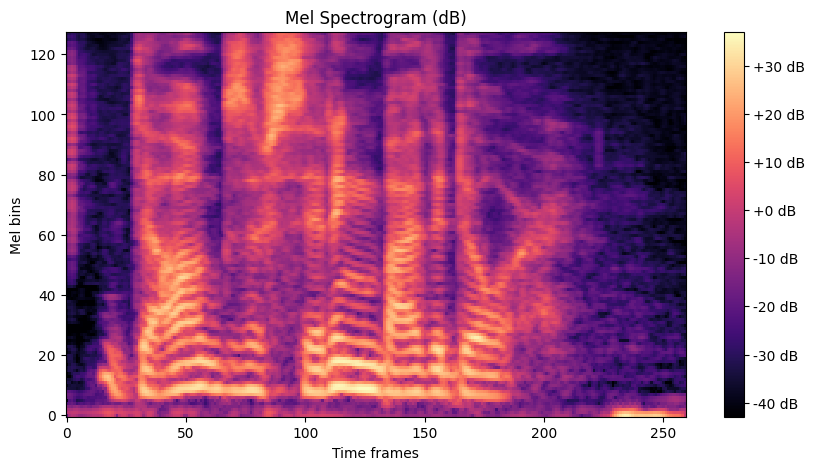

Shape del Mel-Spectrogram: torch.Size([1, 128, 260])


In [20]:
# --- Visualizzazione ---

plt.figure(figsize=(10,5))
# Per matplotlib dobbiamo passare il tensore sulla CPU e convertirlo in NumPy
# dbmelspec[0] prende il primo canale audio (mono)
plt.imshow(dbmelspec[0].cpu().numpy(), origin="lower", aspect="auto", interpolation="nearest", cmap='magma')
plt.title("Mel Spectrogram (dB)")
plt.colorbar(format='%+2.0f dB')
plt.ylabel('Mel bins')
plt.xlabel('Time frames')
plt.show()
# Stampa la shape per ottenere (Canali, n_mels, Time_frames) es. (1, 128, X)
print(f"Shape del Mel-Spectrogram: {dbmelspec.shape}")

# Network Model

In [21]:

class CRNN(nn.Module):
    """
    CRNN Architecture (Choi et al., 2016):
    - 4x Conv2D (3x3 kernel) + BatchNorm + ELU + MaxPool + Dropout(0.1)
    - AdaptiveAvgPool2d -> (freq=1, time=15)
    - 2-layer GRU
    - Last hidden state -> FC -> num_classes
    
    Input: (batch, 1, n_mels, time_frames)  [mel-spectrogram]
    Output: (batch, num_classes)            [logit scores]
    """

    def __init__(self, num_classes: int, n_channels: int = 68,
                 rnn_hidden: int = 68, rnn_layers: int = 2,
                 dropout: float = 0.1):
        super().__init__()

        # ── CNN sub-network ───────────────────────────────────────────────
        # 4 blocchi: Conv2D(3×3) → BatchNorm → ELU → MaxPool → Dropout(0.1)
        # Pooling asimmetrico: riduce la frequenza più velocemente del tempo
        # per preservare abbastanza passi temporali per la GRU.
        #
        # Dimensioni dopo ogni blocco (input: freq=64, time=128):
        #   Block 1: MaxPool(2×2) → (32, 64)
        #   Block 2: MaxPool(2×2) → (16, 32)
        #   Block 3: MaxPool(4×2) → ( 4, 16)
        #   Block 4: MaxPool(4×2) → ( 1,  8)  ← freq=1, time=8 per la GRU

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1,              n_channels,   kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq: 64→32 | time: 128→64
            nn.Dropout(dropout),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(n_channels,   n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq: 32→16 | time:  64→32
            nn.Dropout(dropout),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),   # freq: 16→ 4 | time:  32→16
            nn.Dropout(dropout),
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),   # freq:  4→ 1 | time:  16→ 8
            nn.Dropout(dropout),
        )

           # Garantisce freq=1 e time=8 anche con audio di lunghezza variabile
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 8))
          # ── GRU sub-network ───────────────────────────────────────────────
        # 2-layer GRU come da paper (Sezione 2.4)
        # input_size = feature maps dell'ultimo blocco CNN = n_channels*2
        # seq_len = 8 passi temporali
        self.rnn = nn.GRU(
            input_size=n_channels * 2,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )

        # ── Classificatore ────────────────────────────────────────────────
        # Last hidden state → Linear → 8 emozioni
        # Nessuna Softmax: nn.CrossEntropyLoss la include internamente
        self.fc = nn.Linear(rnn_hidden, num_classes)
     
    def forward(self, x):
        # x: (B, 1, 64, 128)  — mel-spectrogram mono

        # 1. CNN: estrazione feature locali tempo-frequenza
        x = self.conv_block1(x)    # (B,    n_ch, 32, 64)
        x = self.conv_block2(x)    # (B,  2*n_ch, 16, 32)
        x = self.conv_block3(x)    # (B,  2*n_ch,  4, 16)
        x = self.conv_block4(x)    # (B,  2*n_ch,  1,  8)

        # 2. Collassa la dimensione frequenza (freq=1 → squeeze)
        x = self.adaptive_pool(x)  # (B,  2*n_ch,  1,  8)
        x = x.squeeze(2)           # (B,  2*n_ch,  8)

        # 3. Prepara per GRU: (batch, seq_len, features)
        x = x.permute(0, 2, 1)    # (B, 8, 2*n_ch)

        # 4. GRU: aggregazione temporale
        # h_n shape: (num_layers, B, rnn_hidden)
        _, h_n = self.rnn(x)
        x = h_n[-1]                # (B, rnn_hidden) ← last hidden state

        # 5. Classificazione finale
        return self.fc(x)          # (B, num_classes)


# 4. Inizializza il modello con il TUO numero di classi 
NUMERO_EMOZIONI = 8

model_crnn = CRNN(
    num_classes=NUMERO_EMOZIONI,
    n_channels=68,   # Conv1: 68 maps | Conv2-4: 136 maps  (Tabella 1, 0.5M)
    rnn_hidden=68,   # GRU hidden units                    (Tabella 1, 0.5M)
    rnn_layers=2,    # 2-layer GRU                         (Sezione 2.4)
    dropout=0.1      # weak dropout                        (Sezione 2)
)
# ── Shape check ───────────────────────────────────────────────────────────────
_dummy = torch.zeros(2, 1, 64, 128)
with torch.no_grad():
    _out = model_crnn(_dummy)
print(f"Shape check  →  input: {list(_dummy.shape)}   output: {list(_out.shape)}")
assert _out.shape == (2, NUMERO_EMOZIONI), "Shape mismatch!"
print("Forward pass OK\n")

total_params = sum(p.numel() for p in model_crnn.parameters() if p.requires_grad)
print(f"Variante:          0.5M  (n_channels=68, rnn_hidden=68)")
print(f"Parametri totali:  {total_params:,}")
print()
print(model_crnn)

Shape check  →  input: [2, 1, 64, 128]   output: [2, 8]
Forward pass OK

Variante:          0.5M  (n_channels=68, rnn_hidden=68)
Parametri totali:  488,928

CRNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 68, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(68, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(68, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(136, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(136, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(1

# Traning and testing

In [22]:
# UNCOMMENT and CUSTOMIZE with the proper model, transform and criterion (either for 1D or 2D networks)
model = model_crnn
transform = None # transform=None perché la pipeline è già applicata nella collate_fn
criterion = nn.CrossEntropyLoss()

log_interval = 20
n_epoch = 30

# Adam come da paper
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# OneCycleLR per convergenza più rapida
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.001,
    steps_per_epoch=len(train_loader),
    epochs=n_epoch,
    anneal_strategy='linear'
)

model = model.to(device)

pbar_update = 1 / (len(train_loader) + len(test_loader))
losses = []

print(f"Device: {device}")
print(f"Parametri totali: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print()

with tqdm(total=n_epoch) as pbar:
    for epoch in range(1, n_epoch + 1):
        train(model, transform, criterion, optimizer, epoch, log_interval, scheduler)
        test(model, transform, criterion, epoch)


Device: cuda
Parametri totali: 488,928



  0%|          | 0.02564102564102564/30 [00:02<49:53, 99.87s/it]


       Train Epoch: 1 [0/2015 (0%)]
       Loss: 2.116749


  2%|▏         | 0.5384615384615387/30 [00:28<24:58, 50.87s/it]


       Train Epoch: 1 [1280/2015 (62%)]
       Loss: 2.010426


...


       Train Epoch: 30 [0/2015 (0%)]
       Loss: 0.244485


 98%|█████████▊| 29.53846153846144/30 [24:07<00:23, 51.17s/it] 


       Train Epoch: 30 [1280/2015 (62%)]
       Loss: 0.124713


100%|█████████▉| 29.9999999999999/30 [24:28<00:00, 48.96s/it]


Test Epoch: 30	Accuracy: 398/433 (92%)





RISULTATI FINALI SUL TEST SET
Accuracy Generale: 88.43%
F1-Score (Macro): 0.8824


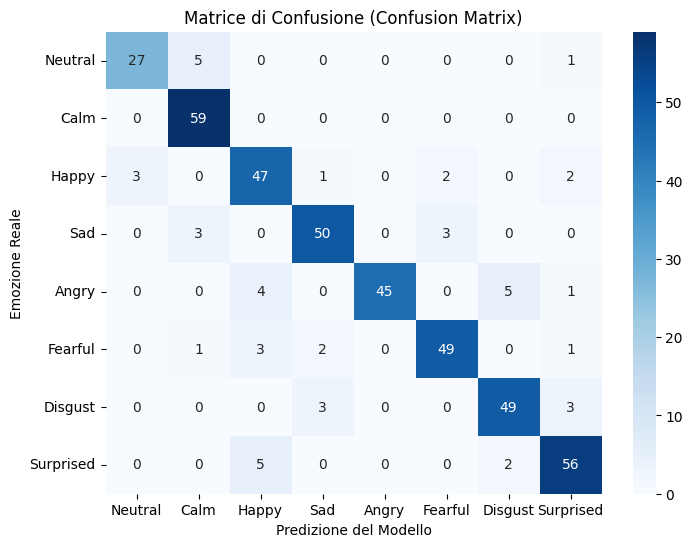



RISULTATI FINALI SUL TEST SET
Accuracy Generale: 91.92%
F1-Score (Macro): 0.9142


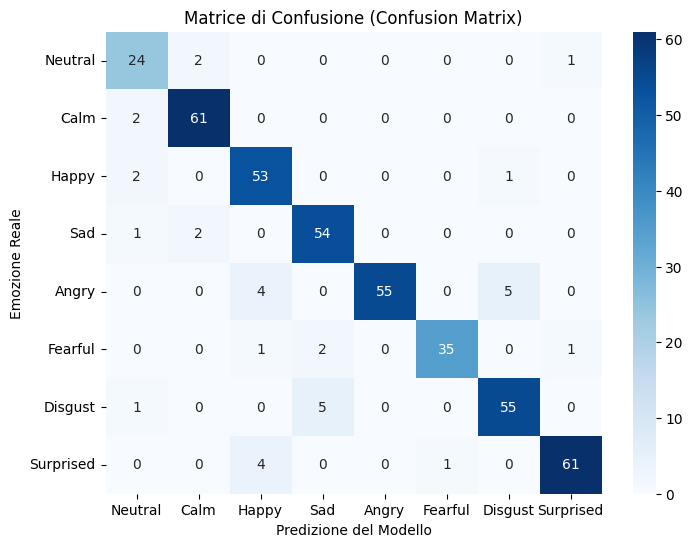

(0.9191685912240185,
 0.9142335555993886,
 array([[24,  2,  0,  0,  0,  0,  0,  1],
        [ 2, 61,  0,  0,  0,  0,  0,  0],
        [ 2,  0, 53,  0,  0,  0,  1,  0],
        [ 1,  2,  0, 54,  0,  0,  0,  0],
        [ 0,  0,  4,  0, 55,  0,  5,  0],
        [ 0,  0,  1,  2,  0, 35,  0,  1],
        [ 1,  0,  0,  5,  0,  0, 55,  0],
        [ 0,  0,  4,  0,  0,  1,  0, 61]]))

In [23]:
# Evaluate on the validation set
print()
evaluate_model(model, val_loader, device, transform=None,
               classes=[emotion_map[i] for i in range(8)])

# Evaluate on the test set
print()
evaluate_model(model, test_loader, device, transform=None,
               classes=[emotion_map[i] for i in range(8)])